### Objective functions for a Schlumberger sounding

In [4]:
import numpy as np
from matplotlib import pyplot as plt
import pygimli as pg
from pygimli.physics.ves import VESModelling
from objfun import showPhiD

We consider a Schlumberger sounding with AB/2 values between 3 and 1000m.

In [5]:
ab2 = np.logspace(0.8, 3.5, 50)
print(ab2)
ves = VESModelling(ab2=ab2, mn2=ab2/3)

[   6.30957344    7.16311693    8.13212567    9.23221952   10.48113134
   11.89899286   13.50865919   15.33607719   17.41070378   19.76598072
   22.4398737    25.47548431   28.92174481   32.83420691   37.2759372
   42.31853379   48.04328036   54.54245649   61.9208251    70.29732115
   79.80696888   90.60305822  102.85961583  116.77421024  132.57113656
  150.505032    170.86498045  193.97917237  220.220195    250.01103826
  283.83191311  322.22799226  365.81819802  415.30517899  471.48663635
  535.26818228  607.67793799  689.88310635  783.20878655  889.15933392
 1009.44260927 1145.99750858 1301.02521691 1477.02469016 1676.83293681
 1903.67074884 2161.194619   2453.55568133 2785.46662501 3162.27766017]


We assume a 3-layer model with a bad conductor embedded into a medium resistive halfspace and later a good conductor.

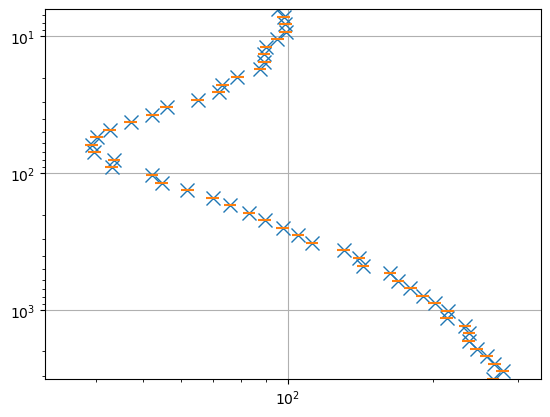

In [10]:
synModel = [15, 15, 100, 10, 300]  # d1, d2, r1, r2, r3
data = ves.response(synModel)
error = 0.03  # 3%
data *= np.random.randn(len(data)) * error + 1.0
fig, ax = plt.subplots()
ax.loglog(data, ab2, "x", ms=10);
ax.errorbar(data, ab2, xerr=data*error, ls="None");
ax.set_xlim(min(data)*0.8, max(data)*1.2)
ax.set_ylim(max(ab2), min(ab2))
ax.grid()

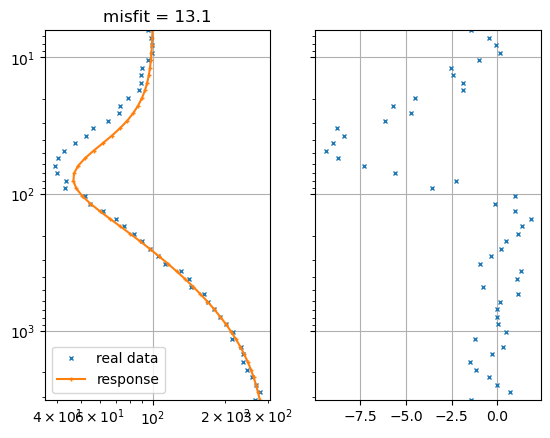

In [11]:
model = np.array(synModel)
model[0] += 5
response = ves.response(model)
misfit = (np.log(data) - np.log(response)) / error
chi2 = np.mean(misfit**2)
fig, ax = plt.subplots(ncols=2, sharey=True)
ax[0].loglog(data, ab2, "x", label="real data");
ax[0].loglog(response, ab2, "+-", label="response");
ax[1].semilogy(misfit, ab2, "x")
ax[1].grid()
ax[0].set_ylim(max(ab2), min(ab2))
ax[0].legend()
ax[0].set_title(f"misfit = {chi2:.1f}")
ax[0].grid()

In [13]:
def checkModel(model):
    response = ves.response(model)
    misfit = (np.log(data) - np.log(response)) / error
    chi2 = np.mean(misfit**2)
    fig, ax = plt.subplots(ncols=2, sharey=True, figsize=[6, 4])
    ax[0].loglog(data, ab2, "x", label="real data");
    ax[0].loglog(response, ab2, "+-", label="response");
    ax[0].set_xlabel(r"$\rho_a$ ($\Omega$m)")
    ax[0].set_ylabel("AB/2 (m)")
    ax[1].semilogy(misfit, ab2, "x")
    ax[1].grid()
    ax[0].set_ylim(max(ab2), min(ab2))
    ax[0].legend()
    ax[0].set_title(f"misfit = {chi2:.1f}")
    ax[0].grid()

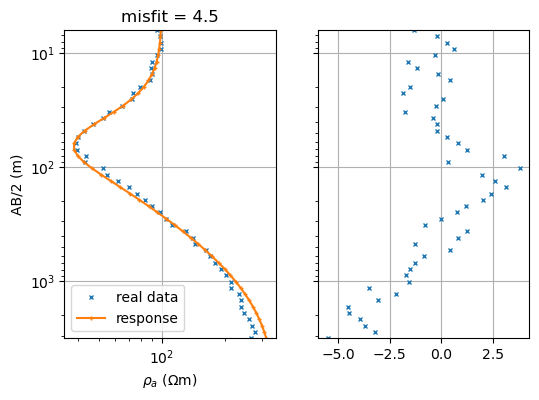

In [29]:
checkModel([16, 10, 100, 6, 350])  # d1, d2, rho1, rho2, rho3

Apparently the model seems to be equivalent within error bounds.

In [30]:
phiD = lambda x, y, err: np.mean((np.log(x)-np.log(y))**2/err**2)
print("phiD=", phiD(data, response, error))
print("chi2=", phiD(data, response, error)/len(data))

phiD= 13.081599333178245
chi2= 0.2616319866635649


Wir betrachten jetzt eine ganze Reihe von Werten für d2 und rho2 und speichern die Zielfunktion in einer Matrix ab, die dann mit `showPhiD` gezeigt wird.

In [31]:
thk2 = np.logspace(0.5, 2, 41)
res2 = np.logspace(0, 2, 41)
M = np.zeros((len(thk2), len(res2)))
for i, model[1] in enumerate(thk2):
    for j, model[3] in enumerate(res2):
        M[i, j] = phiD(data, ves.response(model), error)

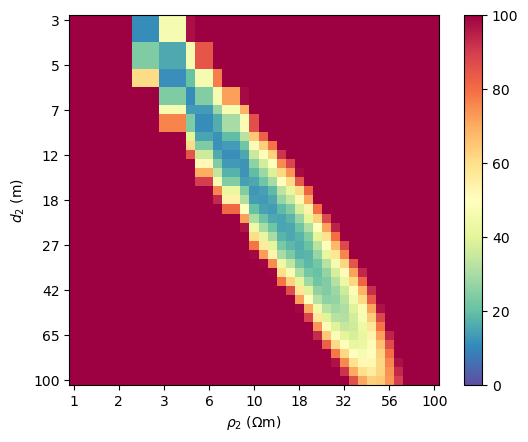

In [32]:
# showPhiD(res2, thk2, np.log10(M), vmin=0, vmax=2);
showPhiD(res2, thk2, M, vmin=0, vmax=100);

In [9]:
print("phiD\tthk\tres\tRhoT")
for i, t in enumerate(thk2):
    ind = np.argmin(M[i, :])
    print("{:.2f}\t{:.2f}\t{:.2f}\t{:.2f}".format(M[i, ind], t, res2[ind], t*res2[ind]))

phiD	thk	res	RhoT
125.04	3.16	2.24	7.08
125.04	3.45	2.24	7.72
125.04	3.76	2.24	8.41
1148.61	4.10	3.16	12.96
1148.61	4.47	3.16	14.13
1148.61	4.87	3.16	15.40
1557.41	5.31	3.16	16.79
1557.41	5.79	3.16	18.30
103.83	6.31	4.47	28.18
103.83	6.88	4.47	30.73
402.16	7.50	5.01	37.58
661.73	8.18	5.01	40.97
661.73	8.91	5.01	44.67
75.97	9.72	6.31	61.31
218.73	10.59	7.08	74.99
354.32	11.55	7.08	81.75
52.18	12.59	8.91	112.20
792.51	13.72	8.91	122.32
485.89	14.96	10.00	149.62
155.03	16.31	11.22	183.02
133.24	17.78	11.22	199.53
312.77	19.39	12.59	244.06
153.30	21.13	14.13	298.54
204.36	23.04	15.85	365.17
512.70	25.12	17.78	446.68
482.39	27.38	17.78	486.97
611.20	29.85	19.95	595.66
1308.62	32.55	19.95	649.38
1164.19	35.48	22.39	794.33
2014.72	38.68	25.12	971.63
2227.34	42.17	25.12	1059.25
2908.91	45.97	28.18	1295.69
3953.75	50.12	28.18	1412.54
4639.46	54.64	31.62	1727.83
6340.50	59.57	35.48	2113.49
7203.79	64.94	35.48	2304.09
9263.12	70.79	39.81	2818.38
11005.55	77.18	39.81	3072.56
13626.59	84.14	44.67	3

We can define an upper limit for the thickness of about 30m and a lower limit for the resistivity of about 600$\Omega$m. Otherwise, all models with the 
same product (about 20k$\Omega$m$^2$) resistivity and thickness are equivalent. This kind of equivalence is known as S equivalence and the transverse resistance.

Now we do the same for a good conducting middle layer.

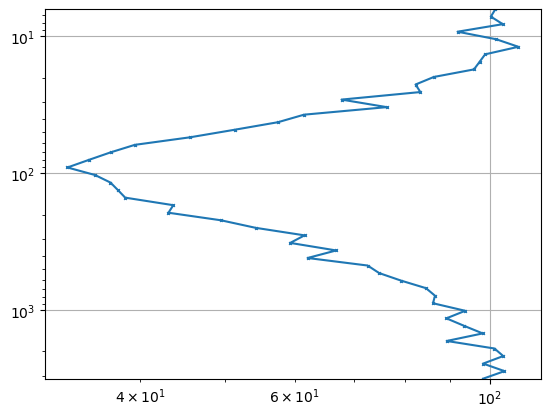

In [10]:
model = [20, 20, 100, 10, 100]  # d1, d2, r1, r2, r3
data = ves.response(model)
error = 0.05
data *= np.random.randn(len(data)) * error + 1.0
fig, ax = plt.subplots()
ax.loglog(data, ab2, "x-");
ax.set_ylim(max(ab2), min(ab2))
plt.grid()

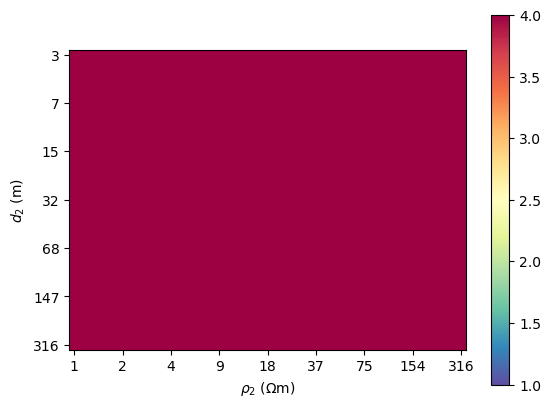

In [11]:
thk2 = np.logspace(0.5, 2.5, 31)
res2 = np.logspace(0, 2.5, 41)
M = np.zeros((len(thk2), len(res2)))
for i, model[1] in enumerate(thk2):
    for j, model[3] in enumerate(res2):
        M[i, j] = phiD(data, ves.response(model), error)

showPhiD(res2, thk2, M);

In [12]:
print("phiD\tthk\tres\tsigmaT")
for i, t in enumerate(thk2):
    ind = np.argmin(M[i, :])
    print("{:.2f}\t{:.2f}\t{:.2f}\t{:.2f}".format(M[i, ind], t, res2[ind], t/res2[ind]))

phiD	thk	res	sigmaT
44.98	3.16	1.54	2.05
45.36	3.69	1.78	2.07
46.06	4.30	2.05	2.09
47.06	5.01	2.37	2.11
48.33	5.84	2.74	2.13
49.85	6.81	3.16	2.15
51.54	7.94	3.65	2.18
53.35	9.26	4.22	2.20
52.75	10.80	5.62	1.92
50.88	12.59	6.49	1.94
49.44	14.68	7.50	1.96
48.57	17.11	8.66	1.98
48.58	19.95	10.00	2.00
50.06	23.26	11.55	2.01
54.08	27.12	13.34	2.03
61.72	31.62	13.34	2.37
64.96	36.87	15.40	2.39
73.74	42.99	17.78	2.42
93.30	50.12	20.54	2.44
131.64	58.43	23.71	2.46
177.01	68.13	23.71	2.87
227.72	79.43	27.38	2.90
321.19	92.61	27.38	3.38
390.95	107.98	31.62	3.41
516.06	125.89	31.62	3.98
617.36	146.78	36.52	4.02
755.20	171.13	36.52	4.69
907.52	199.53	42.17	4.73
1039.99	232.63	42.17	5.52
1204.73	271.23	42.17	6.43
1383.15	316.23	48.70	6.49


We can define upper limits for both the resistivity (of 30$\Omega$m) and the thickness (of 15$\Omega$m). Otherwise, all models with the same ratio of about 2S between resistivity and thickness are equivalent. This kind of equivalence is known as T equivalence and the ratio is the longitudinal conductance.